# Demonstration of the QLSAs workflow on Quantinuum backends

This notebook mirrors the IBM demo workflow (Map → Optimize → Execute → Post-process)
but targets **Quantinuum** hardware and emulators via the Guppy / Nexus bridge.

Two execution modes are supported:
- **Local Selene emulator** (`use_local_emulator=True`): no cloud credentials required, fast.
- **Quantinuum Nexus** (`use_local_emulator=False`): uploads compiled HUGR to Nexus and runs
  on a Quantinuum device or cloud-hosted emulator (H1-1E, H2-1E, Helios-1E, H2-1, …).

In [7]:
# Set system path

from pathlib import Path
import sys


def find_repo_root(start: Path | None = None) -> Path:
    p = (start or Path.cwd()).resolve()
    for d in (p, *p.parents):
        if (d / ".git").exists() or (d / "pyproject.toml").exists() or (d / "src").exists():
            return d
    return p


repo_root = find_repo_root()
print(repo_root)

src_dir = repo_root / "src"
if src_dir.exists() and str(src_dir) not in sys.path:
    sys.path.insert(0, str(src_dir))

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

/Users/adrianharkness/QCOL_COPT/HHL/QLSAs


In [8]:
# Import QLSAs modules

from qlsas.algorithms.hhl import HHL, MCRYEigOracle, ExactReciprocalEigOracle, UCRYEigOracle
from qlsas.state_prep import DefaultStatePrep
from qlsas.readout import MeasureXReadout
from qlsas.transpiler import Transpiler
from qlsas.executer import Executer
from qlsas.solver import QuantumLinearSolver
from qlsas.refiner import Refiner
from qlsas.quantinuum_config import QuantinuumBackendConfig
from linear_systems_problems.random_matrix_generator_v2 import generate_problem

# Other imports
from datetime import datetime
import numpy as np
import math
import matplotlib.pyplot as plt

%config InlineBackend.figure_format = "retina"

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
})

## Step 0: **Define** the (classical) problem

In [9]:
n = 16
prob = generate_problem(n=n, cond_number=5, sparsity=0.5, seed=0)
A, b = prob["A"], prob["b"]

A = A / np.linalg.norm(b)
b = b / np.linalg.norm(b)

print(f"A:\n{A}")
print(f"\nb: {b}")
print(f"\nmin eigenvalue: {np.min(np.linalg.eigvalsh(A)):.6f}")
print(f"max eigenvalue: {np.max(np.linalg.eigvalsh(A)):.6f}")
print(f"condition number: {np.linalg.cond(A):.4f}")
print(f"sparsity: {np.sum(A != 0) / (n * n):.4f}")

A:
[[ 3.45819472e-01  0.00000000e+00  8.70829253e-02  0.00000000e+00
   0.00000000e+00  2.07776774e-02 -2.15292759e-04  8.40732190e-02
  -5.65429621e-02 -2.39700939e-02  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  1.27825956e-02  0.00000000e+00]
 [ 0.00000000e+00  4.45221846e-01  0.00000000e+00 -6.02217307e-02
   6.30294964e-02  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  3.09551501e-02 -1.05754048e-02
  -1.12381529e-01  1.99751195e-03  0.00000000e+00  0.00000000e+00]
 [ 8.70829253e-02  0.00000000e+00  4.63207679e-01  2.61420427e-02
   0.00000000e+00  9.47500692e-02  7.04741613e-02  0.00000000e+00
   6.35662003e-02  0.00000000e+00  0.00000000e+00  1.06432418e-02
   0.00000000e+00  0.00000000e+00  7.31762652e-02 -6.26494001e-03]
 [ 0.00000000e+00 -6.02217307e-02  2.61420427e-02  4.14430482e-01
   0.00000000e+00  0.00000000e+00  1.03756564e-02  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00 -3.59374092e-02
  -3

## Step 1: **Map** problem to quantum circuits and operators

In [10]:
oracle = UCRYEigOracle()  # MCRYEigOracle() or ExactReciprocalEigOracle()

hhl = HHL(
    num_qpe_qubits=int(math.log2(len(b))),
    eig_oracle=oracle,
)

In [11]:
sp = DefaultStatePrep()
qlsa_circuit = hhl.build_circuit(A, b, sp)
readout = MeasureXReadout()
hhl_circuit = readout.apply(qlsa_circuit)
hhl_circuit.draw(output="mpl", fold=-1)

## Step 2: **Optimize** for Quantinuum hardware

Configure a `QuantinuumBackendConfig`. The transpiler converts the Qiskit circuit
to an optimised pytket circuit rebased to the Quantinuum gate set (CX, Rz, H, ZZMax).

### Backend options

| Option | `device_name` | `use_local_emulator` | Notes |
|---|---|---|---|
| Local Selene | any | `True` | No credentials, fastest for prototyping |
| Cloud emulator | `"H1-1E"` / `"H2-1E"` / `"Helios-1E"` | `False` | Nexus account required |
| Real hardware | `"H2-1"` / `"Helios-1"` | `False` | Nexus account + allocation required |

In [12]:
# --- Choose a backend ---

# Option A: local Selene emulator (no credentials needed)
# backend = QuantinuumBackendConfig(
#     device_name="H2-1E",
#     n_qubits=hhl_circuit.num_qubits,
#     use_local_emulator=True,
#     seed=42,
# )

# Option B: Quantinuum cloud emulator via Nexus (comment out Option A above)
# backend = QuantinuumBackendConfig(
#     device_name="H2-1E",
#     n_qubits=hhl_circuit.num_qubits,
#     use_local_emulator=False,
#     noisy_simulation=True,
#     project_name="QLSAs",
# )

# Option C: real Quantinuum hardware via Nexus
backend = QuantinuumBackendConfig(
    device_name="H2-2",
    n_qubits=hhl_circuit.num_qubits,
    use_local_emulator=False,
    project_name="QLSAs",
)

print(f"Backend: {backend.name}")
print(f"  device_name       : {backend.device_name}")
print(f"  use_local_emulator: {backend.use_local_emulator}")
print(f"  n_qubits          : {backend.n_qubits}")

Backend: H2-2
  device_name       : H2-2
  use_local_emulator: False
  n_qubits          : 9


In [13]:
# Log into Nexus (only required for cloud execution, Options B / C)
import qnexus as qnx
qnx.login()

🌐 Browser log in initiated.


╭────────────────────────────────────────────────────────────────────────────────────────╮
│                                                                                        │
│         Confirm that the browser shows the following code and click 'allow device':    │
│                                                                                        │
│                                      6RulJW                                            │
│                                                                                        │
╰────────────────────────────────────────────────────────────────────────────────────────╯

Browser didn't open automatically? Use this link: https://nexus.quantinuum.com/auth/device/browser?otp=6RulJWf0pyjJC5uoMovocWksieKo9OGL_AS1IUypVXi04hy5K_McYVCoaH8t8tb00TZ7lyfdu-Y81WcIwe2gTw
✅ Successfully logged in as adh323@lehigh.edu using the browser.


In [14]:
# Transpile the circuit to pytket / Quantinuum gate set

# Decompose high-level gates into the Quantinuum elementary gate set at
# optimization_level=0 for a fair baseline comparison.
_decomposer = Transpiler(circuit=hhl_circuit, backend=backend, optimization_level=0)
_decomposed = _decomposer.optimize()
orig_2q    = _decomposed.n_2qb_gates()
orig_total = _decomposed.n_gates
orig_depth = _decomposed.depth()

transpiler = Transpiler(
    circuit=hhl_circuit,
    backend=backend,
    optimization_level=2,
)
transpiled_hhl_circuit = transpiler.optimize()

opt_2q    = transpiled_hhl_circuit.n_2qb_gates()
opt_total = transpiled_hhl_circuit.n_gates
opt_depth = transpiled_hhl_circuit.depth()

def _pct(before, after):
    return 100 * (before - after) / before if before else float("nan")

print(f"{'Metric':<18} {'Original':>10} {'Optimised':>10} {'Reduction':>10}")
print("-" * 52)
print(f"{'2q-gate count':<18} {orig_2q:>10} {opt_2q:>10} {_pct(orig_2q, opt_2q):>9.1f}%")
print(f"{'Total gates':<18} {orig_total:>10} {opt_total:>10} {_pct(orig_total, opt_total):>9.1f}%")
print(f"{'Depth':<18} {orig_depth:>10} {opt_depth:>10} {_pct(orig_depth, opt_depth):>9.1f}%")
print(f"{'Qubits':<18} {transpiled_hhl_circuit.n_qubits:>10}")

Metric               Original  Optimised  Reduction
----------------------------------------------------
2q-gate count            1497       1497       0.0%
Total gates              2486       2486       0.0%
Depth                    2393       2393       0.0%
Qubits                      9


## Step 3: **Execute** on target hardware

In [15]:
executer = Executer()

counts = executer.run(
    transpiled_circuit=transpiled_hhl_circuit,
    backend=backend,
    shots=1000,
    register_infos=transpiler.register_infos,
    measurement_plan=transpiler.measurement_plan,
)

print(f"\nTotal shots returned: {sum(counts.values())}")
print(f"Distinct bitstrings : {len(counts)}")

ResourceFetchFailed: Failed to fetch resource with status code: 404, message: {"detail":"Not Found"}

## Step 4: **Process** result to obtain classical solution

In [ ]:
readout_pp = MeasureXReadout()
solution, success_rate, residual = readout_pp.process(counts, A, b)

print(f"Success rate : {success_rate:.4f}")
print(f"Residual     : {residual:.6e}")
print(f"Solution     : {solution}")

total shots: 1000
num_successful_shots: 159
success rate: 0.159
solver residual: 0.20931859981530393
Success rate : 0.1590
Residual     : 2.093186e-01
Solution     : [-0.13736056  0.11215443  0.13736056  0.32698355  0.         -0.26302545
 -0.22430886 -0.19425717 -0.35466345  0.20982173  0.13736056  0.44861772
 -0.15861032  0.34568317  0.07930516  0.38033418]


## Wrap steps 1–4 in a solver

In [ ]:
hhl_solver = QuantumLinearSolver(
    qlsa=hhl,
    readout=MeasureXReadout(),
    backend=backend,
    target_successful_shots=1000,
    shots_per_batch=5000,
    optimization_level=2,
)

## Integrate **Iterative Refinement** to improve accuracy

IR Iteration: 0
>>> Running on Selene emulator (n_qubits=9, shots=1024)
  residual: 0.2006, error: 0.1694, alpha: 3.5381

IR Iteration: 1
>>> Running on Selene emulator (n_qubits=9, shots=1024)
  residual: 0.0589, error: 0.0509, alpha: 1.0966

IR Iteration: 2
>>> Running on Selene emulator (n_qubits=9, shots=1024)
  residual: 0.0121, error: 0.0093, alpha: 0.7288

IR Iteration: 3
>>> Running on Selene emulator (n_qubits=9, shots=1024)
  residual: 0.0033, error: 0.0025, alpha: 0.2920

IR Iteration: 4
>>> Running on Selene emulator (n_qubits=9, shots=1024)
  residual: 0.0005, error: 0.0004, alpha: 0.1436

IR Iteration: 5
>>> Running on Selene emulator (n_qubits=9, shots=1024)
  residual: 0.0001, error: 0.0001, alpha: 0.0552



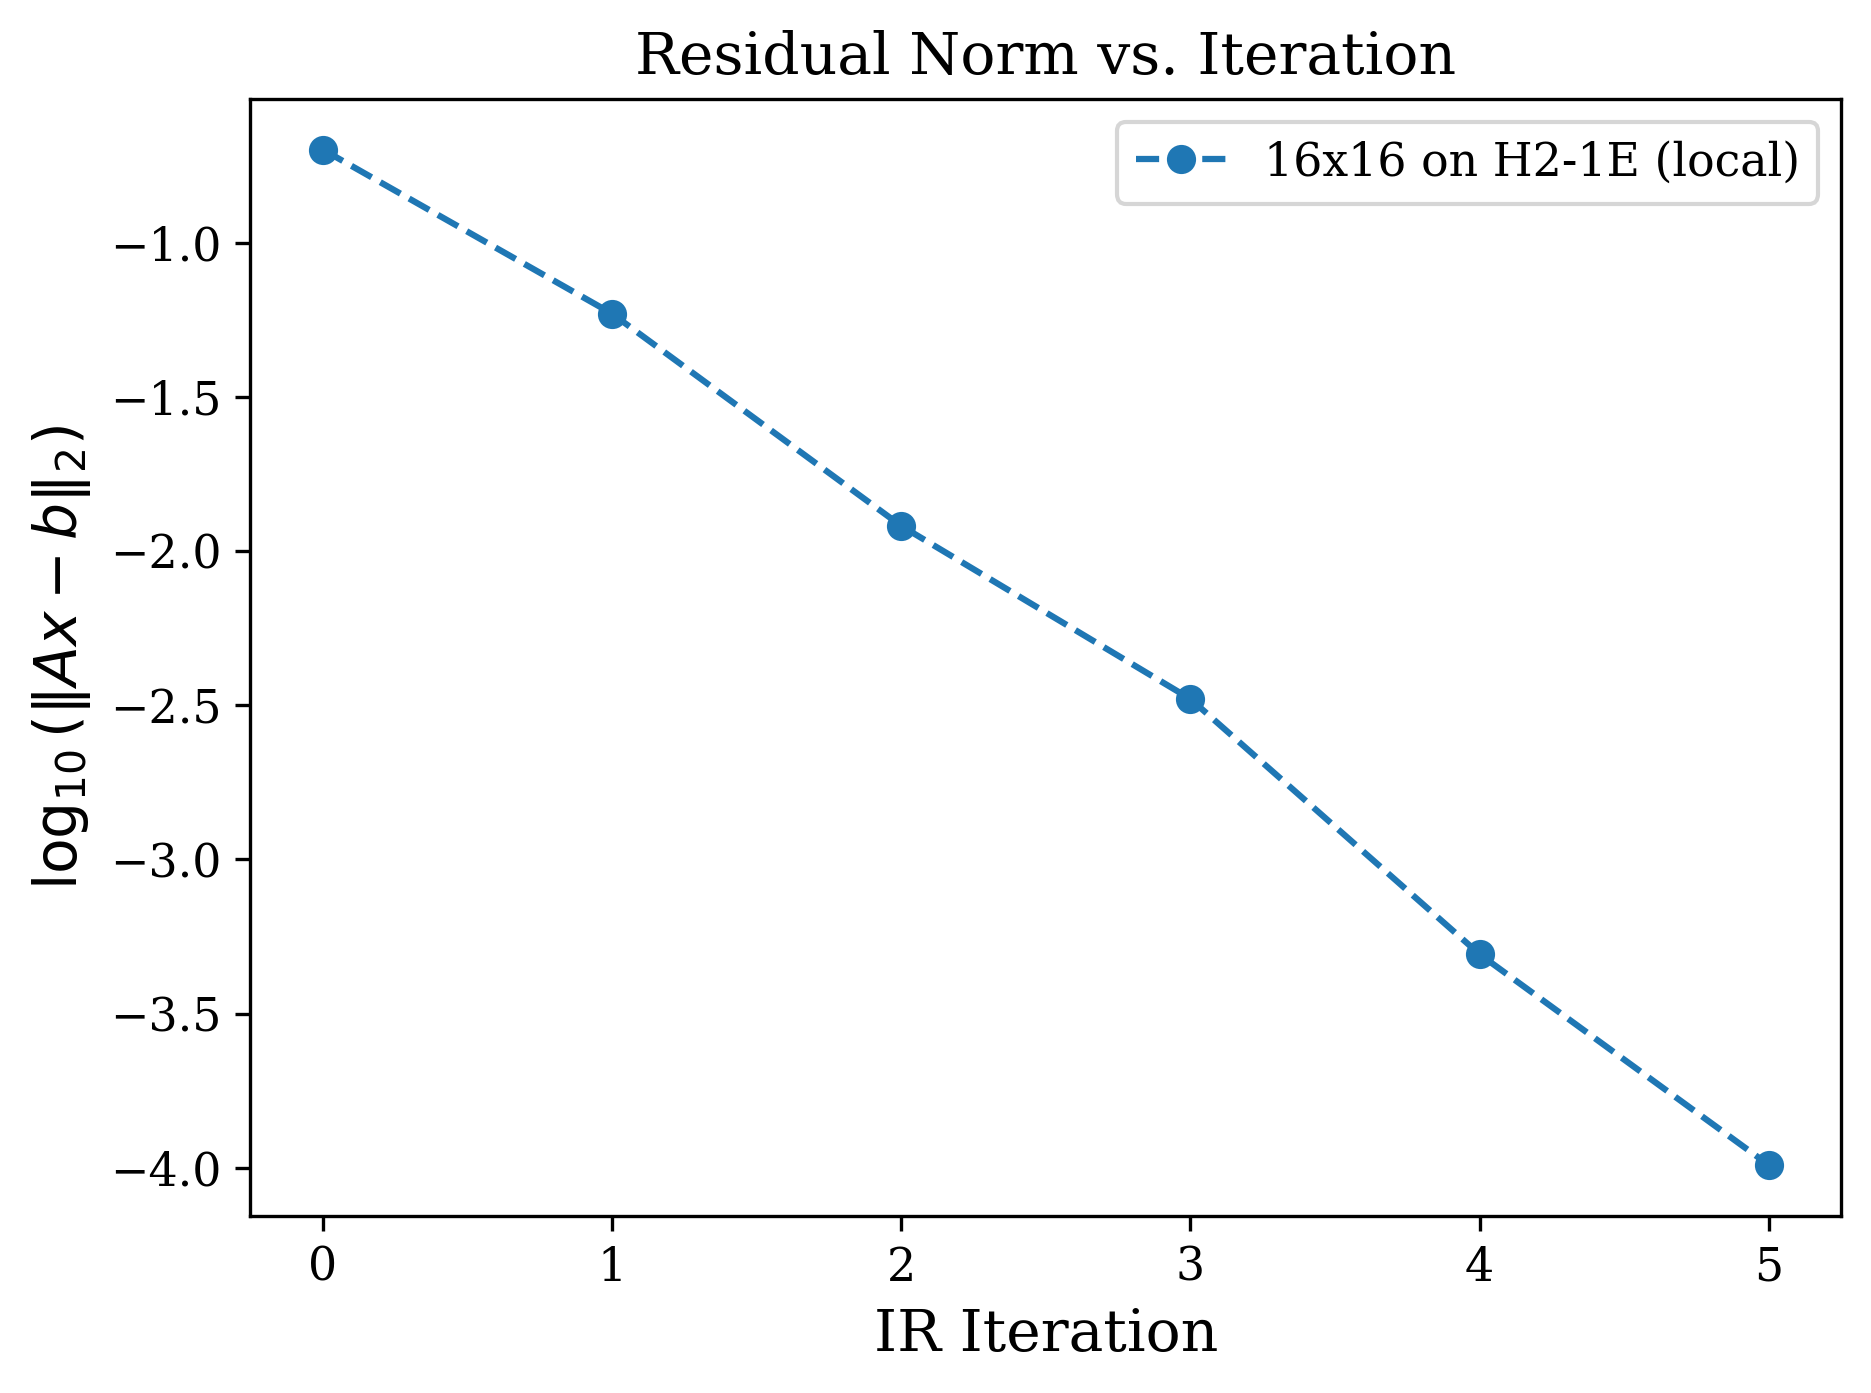

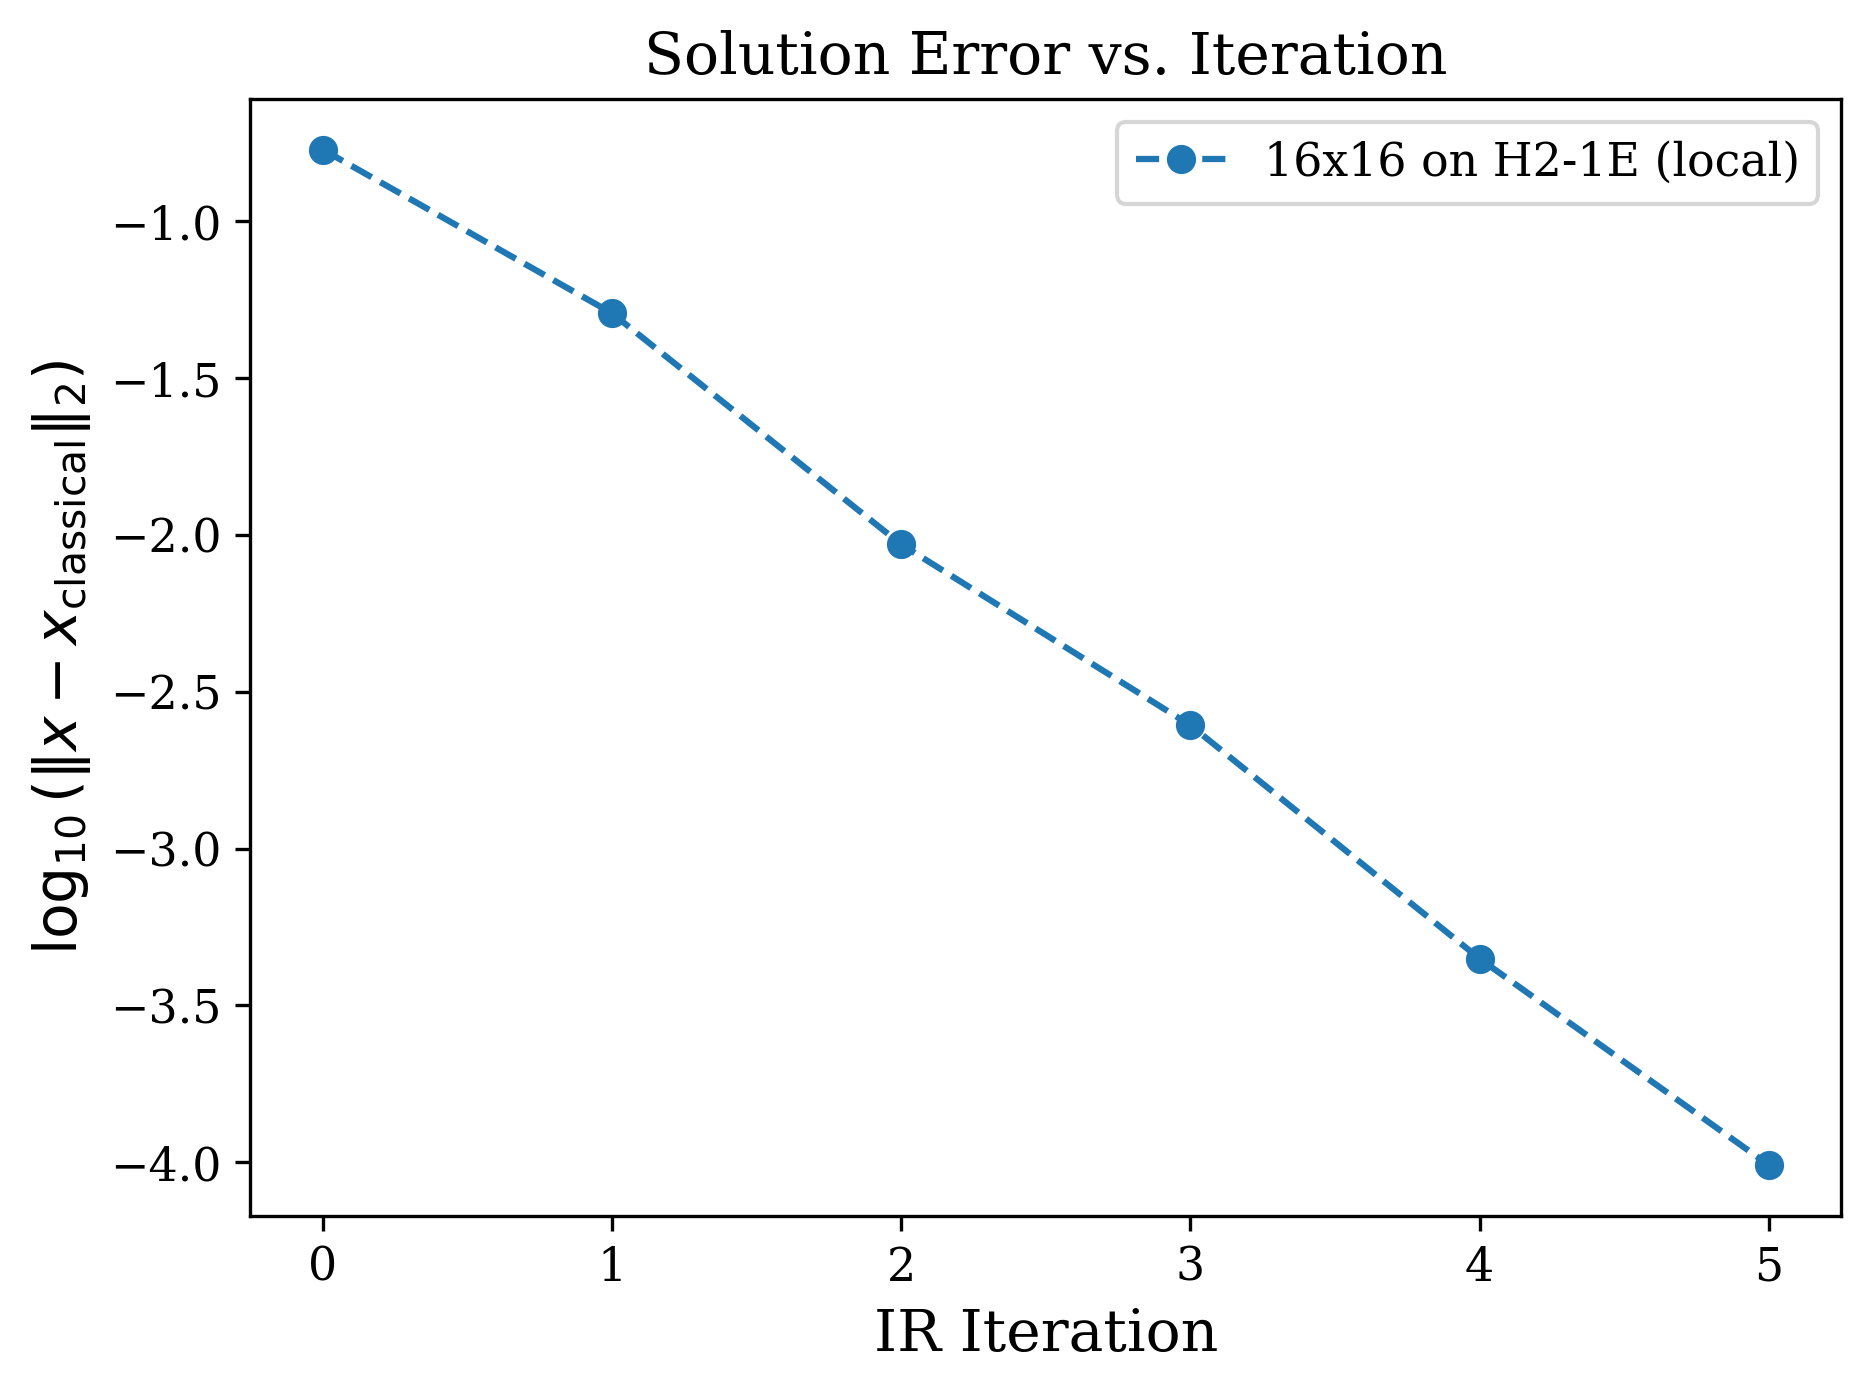

In [ ]:
refiner = Refiner(A=A, b=b, solver=hhl_solver)
refined_solution = refiner.refine(precision=1e-9, max_iter=5, plot=True)

## Compare: local emulator vs. cloud emulator (noisy simulation)

Re-run the same workflow with the Nexus cloud emulator (`noisy_simulation=True`) to compare
convergence under realistic noise. Requires a Nexus account and `qnexus` credentials.

In [ ]:
# Cloud emulator with noisy simulation
noisy_backend = QuantinuumBackendConfig(
    device_name="H2-1E",
    n_qubits=hhl_circuit.num_qubits,
    use_local_emulator=False,
    noisy_simulation=True,
    project_name="QLSAs",
)

noisy_solver = QuantumLinearSolver(
    qlsa=hhl,
    readout=MeasureXReadout(),
    backend=noisy_backend,
    target_successful_shots=1000,
    shots_per_batch=5000,
    optimization_level=2,
)

noisy_refiner = Refiner(A=A, b=b, solver=noisy_solver)
noisy_refined_solution = noisy_refiner.refine(precision=1e-9, max_iter=15, plot=True)

IR Iteration: 0


ResourceFetchFailed: Failed to fetch resource with status code: 404, message: {"detail":"Not Found"}

In [ ]:
residuals       = np.asarray(refined_solution["residuals"], dtype=float)
noisy_residuals = np.asarray(noisy_refined_solution["residuals"], dtype=float)

iterations       = np.arange(1, len(residuals) + 1)
noisy_iterations = np.arange(1, len(noisy_residuals) + 1)

fig, ax = plt.subplots(figsize=(7.0, 4.5), constrained_layout=True)

ax.plot(
    iterations,
    residuals,
    label="Local Selene emulator",
    color="#4C78A8",
    marker="o",
    linewidth=2.2,
    markersize=6,
    markerfacecolor="white",
    markeredgewidth=1.4,
)
ax.plot(
    noisy_iterations,
    noisy_residuals,
    label=f"{noisy_backend.device_name} (noisy simulation)",
    color="#F58518",
    marker="s",
    linewidth=2.2,
    markersize=6,
    markerfacecolor="white",
    markeredgewidth=1.4,
)

ax.set_yscale("log")
ax.set_xlabel("Iterative refinement iteration")
ax.set_ylabel(r"Residual norm $\|Ax-b\|_2$")
ax.set_title("Residual convergence: local vs. noisy Quantinuum emulator")
ax.grid(True, which="major", linestyle="--", linewidth=0.7, alpha=0.5)
ax.grid(True, which="minor", linestyle=":", linewidth=0.5, alpha=0.25)
ax.legend(frameon=False, loc="best")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.show()

In [ ]:
import pickle

solutions_dir = repo_root / "data" / "solutions"
solutions_dir.mkdir(parents=True, exist_ok=True)

solution_dicts = {
    "quantinuum_refined_solution": refined_solution,
    "quantinuum_noisy_refined_solution": noisy_refined_solution,
}

for name, sol in solution_dicts.items():
    out_path = solutions_dir / f"{name}.pkl"
    with open(out_path, "wb") as f:
        pickle.dump(sol, f)
    print(f"Saved {out_path}")